<a href="https://colab.research.google.com/github/Bit-Byte-Builder/Fraud-Detection-in-Online-Transactions/blob/main/Fraud_Detection_Capstone_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔍 Fraud Detection in Online Transactions
## Capstone Project — Data Science with GenAI | Career247
### PaySphere Digital Payments Pvt. Ltd.

---
**Prepared by:** *[Sachin Kumar] | Reg ID: [24CRD02267]*  
**Dataset:** `transactions_fraud.csv` — 50,000 transactions  
**Objective:** Build a machine-learning-driven fraud classification pipeline for real-time transaction scoring.

---


## 📋 Table of Contents

| # | Section | Description |
|---|---------|-------------|
| 1 | Business Problem & Objectives | Context, goals, success metrics |
| 2 | Data Loading & Overview | Load dataset, understand schema |
| 3 | Data Validation & Quality Assessment | Integrity, logic, range checks |
| 4 | Exploratory Data Analysis (EDA) | Distributions, patterns, correlations |
| 5 | Feature Engineering | 10 new engineered features |
| 6 | Data Preprocessing | Encoding, scaling, class imbalance |
| 7 | Model Training | Logistic Regression, Random Forest, XGBoost |
| 8 | Model Evaluation | ROC, PR curves, metrics comparison |
| 9 | Threshold Tuning | Business-optimal fraud cut-off |
| 10 | Feature Importance | Key fraud signals |
| 11 | Fraud Risk Scoring | Risk tiers & operational actions |
| 12 | Business Insights & Recommendations | Actionable fraud strategy |
| 13 | Project Summary | Key findings & next steps |

---
## Section 1 — Business Problem & Analytical Objectives

### 1.1 Company Context
**PaySphere Digital Payments Pvt. Ltd.** processes over **65 million monthly transactions** across UPI, debit/credit cards, net banking, and wallets — serving e-commerce, travel, gaming, and utility sectors.

### 1.2 Problem Statement
PaySphere's Fraud Risk & Compliance Division has observed:
- A **38% rise** in attempted fraudulent transactions over the last quarter
- Rising **false negatives** (missed fraud → chargebacks)
- Growing **false positives** (genuine customers blocked → revenue loss)
- Severe **class imbalance** — fraud forms a small minority of total transactions
- Difficulty distinguishing **legitimate anomalous behaviour** from malicious activity

### 1.3 Analytical Objectives
1. Identify transaction-level and behavioural signals predictive of fraud
2. Engineer meaningful risk-based features (velocity, deviation, device/location risk)
3. Handle class imbalance through appropriate resampling/algorithmic techniques
4. Train and evaluate classification models optimising Recall while controlling Precision
5. Tune fraud decision threshold for business-aligned risk tolerance
6. Deliver a risk-scoring mechanism with actionable operational tiers

### 1.4 Success Metrics
| Metric | Target |
|--------|--------|
| Fraud Recall (True Positive Rate) | ≥ 85% |
| False Positive Rate | ≤ 10% |
| PR-AUC | ≥ 0.90 |
| ROC-AUC | ≥ 0.95 |

### 1.5 Stakeholders
| Team | Interest |
|------|---------|
| Fraud Risk & Compliance | Reduce fraud losses, regulatory adherence |
| Payments Engineering | Integrate real-time scoring into gateway |
| Data Science & AI | Deign of fraud detection models
| Customer Experience | Minimise false positives blocking genuine users |
| Finance & Chargeback | Reduce chargeback volume and merchant disputes |

## 2. Import libraries

In [75]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Settings
import warnings
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

This cell imports the required libraries for data analysis, visualization, preprocessing, model training, and evaluation. We use Pipeline and ColumnTransformer because they make the workflow cleaner and reduce leakage during preprocessing.

##  SECTION 1: DATASET LOADING & INITIAL INSPECTION

## Explanation
In this section, we load the dataset, inspect its dimensions, review available columns, and compare the actual schema with the expected fields from the project data definition. This helps confirm whether the uploaded dataset fully supports all project requirements.


In [76]:
# Load dataset
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Datasets /transactions_fraud.csv")

# Preview
print("First 5 rows:")
display(df.head())

# Shape of dataset
print("Dataset Shape:", df.shape)

# Column names
print("\nOriginal Columns:")
print(df.columns.tolist())

# Standardize column names
df.columns = (
    df.columns.str.lower()
              .str.strip()
              .str.replace(" ", "", regex=False)
              .str.replace("_", "", regex=False)
)

print("\nCleaned Columns:")
print(df.columns.tolist())

# Data types and non-null counts
print("\nDataset Info:")
print(df.info())

# Expected columns from project definition
expected_columns = [
    'transactionid','customerid','deviceid','merchantid','timestamp','amount',
    'paymentmethod','isinternational','merchantcategory','ipaddressriskscore',
    'devicetrustscore','velocity1h','velocity24h','velocity7d',
    'customertenuredays','historicalfraudrate','merchanthistoricalfraudrate',
    'ipaddresscountrymatch','previouschargebackcount','timeofday','dayofweek',
    'isweekend','locationriskscore','transactionsuccessratecustomer','isfraud'
]

actual_columns = df.columns.tolist()

missing_columns = [col for col in expected_columns if col not in actual_columns]
extra_columns = [col for col in actual_columns if col not in expected_columns]

print("\nMissing Columns from Expected Schema:")
print(missing_columns)

print("\nExtra / Alternative Columns in Actual Dataset:")
print(extra_columns)

First 5 rows:


,transaction_id,customer_id,device_id,merchant_id,timestamp,amount,payment_method,is_international,merchant_category,ip_address_risk_score,device_trust_score,txn_count_last_24h,avg_amount_last_24h,merchant_diversity_last_7d,device_change_flag,location_change_flag,authentication_method,otp_success_rate_customer,past_fraud_count_customer,past_disputes_customer,merchant_historical_fraud_rate,hour_of_day,day_of_week,is_weekend,is_fraud
0,1,1357,20937,720,1/18/24 19:23,18780.52,WALLET,0,Travel,0.243550,0.116606,7,6055.25,3,0,0,NONE,0.769328,1,2,0.069502,19,3,0,0
1,2,4095,29542,764,3/30/24 2:22,18955.06,CARD,0,Electronics,0.119761,0.030579,1,13366.74,5,0,1,OTP,0.468411,1,1,0.010010,2,5,1,0
2,3,3618,25236,671,1/4/24 17:26,10743.34,UPI,0,Fashion,0.565367,0.183770,0,7359.14,4,0,0,PIN,0.464356,0,1,0.118434,17,3,0,0
3,4,2755,29904,624,1/27/24 16:00,5054.75,CARD,0,Utilities,0.843842,0.717286,5,10923.57,6,0,0,PIN,0.635799,0,3,0.114947,16,5,1,0
4,5,2732,24151,501,2/20/24 23:14,14799.50,CARD,0,Gaming,0.202402,0.041616,11,6027.72,10,1,0,OTP,0.684301,2,0,0.014550,23,1,0,0


Dataset Shape: (50000, 25)

Original Columns:
['transaction_id', 'customer_id', 'device_id', 'merchant_id', 'timestamp', 'amount', 'payment_method', 'is_international', 'merchant_category', 'ip_address_risk_score', 'device_trust_score', 'txn_count_last_24h', 'avg_amount_last_24h', 'merchant_diversity_last_7d', 'device_change_flag', 'location_change_flag', 'authentication_method', 'otp_success_rate_customer', 'past_fraud_count_customer', 'past_disputes_customer', 'merchant_historical_fraud_rate', 'hour_of_day', 'day_of_week', 'is_weekend', 'is_fraud']

Cleaned Columns:
['transactionid', 'customerid', 'deviceid', 'merchantid', 'timestamp', 'amount', 'paymentmethod', 'isinternational', 'merchantcategory', 'ipaddressriskscore', 'devicetrustscore', 'txncountlast24h', 'avgamountlast24h', 'merchantdiversitylast7d', 'devicechangeflag', 'locationchangeflag', 'authenticationmethod', 'otpsuccessratecustomer', 'pastfraudcountcustomer', 'pastdisputescustomer', 'merchanthistoricalfraudrate', 'hourof

## Interpretation
The dataset contains transaction-level fraud data with features related to amount, payment method, device behavior, merchant fraud history, authentication, and customer dispute behavior. However, the uploaded CSV does not exactly match the official data dictionary, so some expected features such as velocity1h, velocity24h, customer tenure, location risk, and transaction success rate are unavailable and must be replaced with the closest available proxy variables.

## SECTION 2: DATA VALIDATION & QUALITY CHECKS

## Explanation
This section validates the integrity of the dataset by checking duplicates, missing values, invalid target labels, negative transaction amounts, score ranges, and timestamp conversion. The project brief explicitly requires checking nulls, logical violations, and date correctness before further analysis.

In [77]:
# Convert timestamp
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

# Missing values report
missing_report = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing %": (df.isnull().sum() / len(df)) * 100
}).sort_values(by="Missing %", ascending=False)

print("Missing Values Report:")
display(missing_report)

# Duplicate transaction IDs
duplicate_txn = df["transactionid"].duplicated().sum()
print("Duplicate transaction IDs:", duplicate_txn)

# Negative transaction amounts
negative_amounts = (df["amount"] < 0).sum()
print("Negative amount values:", negative_amounts)

# Invalid fraud labels
invalid_target = (~df["isfraud"].isin([0, 1])).sum()
print("Invalid target labels:", invalid_target)

# Invalid timestamp parsing
null_timestamps = df["timestamp"].isna().sum()
print("Null timestamps after datetime conversion:", null_timestamps)

# Score range checks
score_cols = [
    "ipaddressriskscore",
    "devicetrustscore",
    "otpsuccessrate",
    "merchanthistoricalfraudrate"
]

for col in score_cols:
    if col in df.columns:
        invalid_range = ((df[col] < 0) | (df[col] > 1)).sum()
        print(f"{col} values outside [0, 1]:", invalid_range)

# Binary column checks
binary_cols = ["isinternational", "devicechangeflag", "locationchangeflag", "isweekend", "isfraud"]
for col in binary_cols:
    if col in df.columns:
        invalid_binary = (~df[col].isin([0, 1])).sum()
        print(f"{col} invalid binary values:", invalid_binary)

Missing Values Report:


,Missing Count,Missing %
transactionid,0,0.0
customerid,0,0.0
deviceid,0,0.0
merchantid,0,0.0
timestamp,0,0.0
amount,0,0.0
paymentmethod,0,0.0
isinternational,0,0.0
merchantcategory,0,0.0
ipaddressriskscore,0,0.0


Duplicate transaction IDs: 0
Negative amount values: 0
Invalid target labels: 0
Null timestamps after datetime conversion: 0
ipaddressriskscore values outside [0, 1]: 0
devicetrustscore values outside [0, 1]: 0
merchanthistoricalfraudrate values outside [0, 1]: 0
isinternational invalid binary values: 0
devicechangeflag invalid binary values: 0
locationchangeflag invalid binary values: 0
isweekend invalid binary values: 0
isfraud invalid binary values: 0


## Interpretation
The dataset should be considered usable only after validation confirms there are no duplicate transaction IDs, invalid fraud labels, or logically impossible values. Score-based features such as IP risk, device trust, OTP success rate, and merchant historical fraud rate should lie between 0 and 1, while binary flags such as international status and weekend indicator should contain only 0 or 1.

## SECTION 3: EXPLORATORY DATA ANALYSIS

## Explanation
This section explores fraud distribution and identifies patterns across transaction amount, payment method, merchant category, authentication type, international flag, device change, and location change. The project brief specifically asks for exploratory fraud analysis before model building.

Fraud Class Distribution:
isfraud
0    44972
1     5028
Name: count, dtype: int64

Fraud Rate: 0.10056


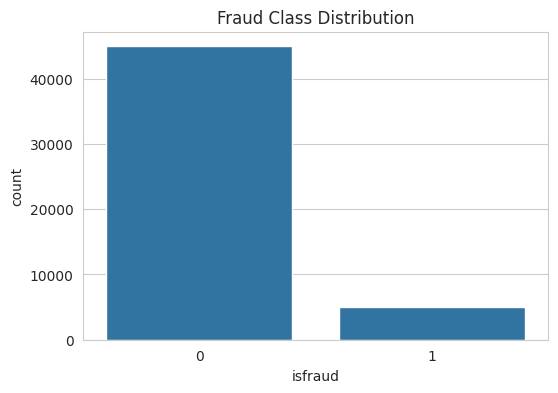

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
transactionid,50000.0,NaN,NaN,NaN,25000.5,1.0,12500.75,25000.5,37500.25,50000.0,14433.901067
customerid,50000.0,NaN,NaN,NaN,2997.25424,1000.0,1994.0,3002.0,3996.0,4999.0,1155.746991
deviceid,50000.0,NaN,NaN,NaN,25002.29148,20000.0,22513.0,25010.5,27496.0,29999.0,2883.264316
merchantid,50000.0,NaN,NaN,NaN,650.02924,500.0,575.0,650.0,725.0,799.0,86.47709
timestamp,50000,NaN,NaN,NaN,2024-02-15 01:03:45.368399872,2024-01-01 00:01:00,2024-01-23 15:46:45,2024-02-15 03:35:30,2024-03-08 10:27:30,2024-03-30 23:55:00,NaN
amount,50000.0,NaN,NaN,NaN,10015.213203,50.51,5007.7125,9971.515,15017.2825,19999.08,5756.852793
paymentmethod,50000,4,UPI,27573,NaN,NaN,NaN,NaN,NaN,NaN,NaN
isinternational,50000.0,NaN,NaN,NaN,0.02958,0.0,0.0,0.0,0.0,1.0,0.169427
merchantcategory,50000,6,Electronics,8399,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ipaddressriskscore,50000.0,NaN,NaN,NaN,0.499724,0.000026,0.250929,0.498304,0.749212,0.999984,0.287707


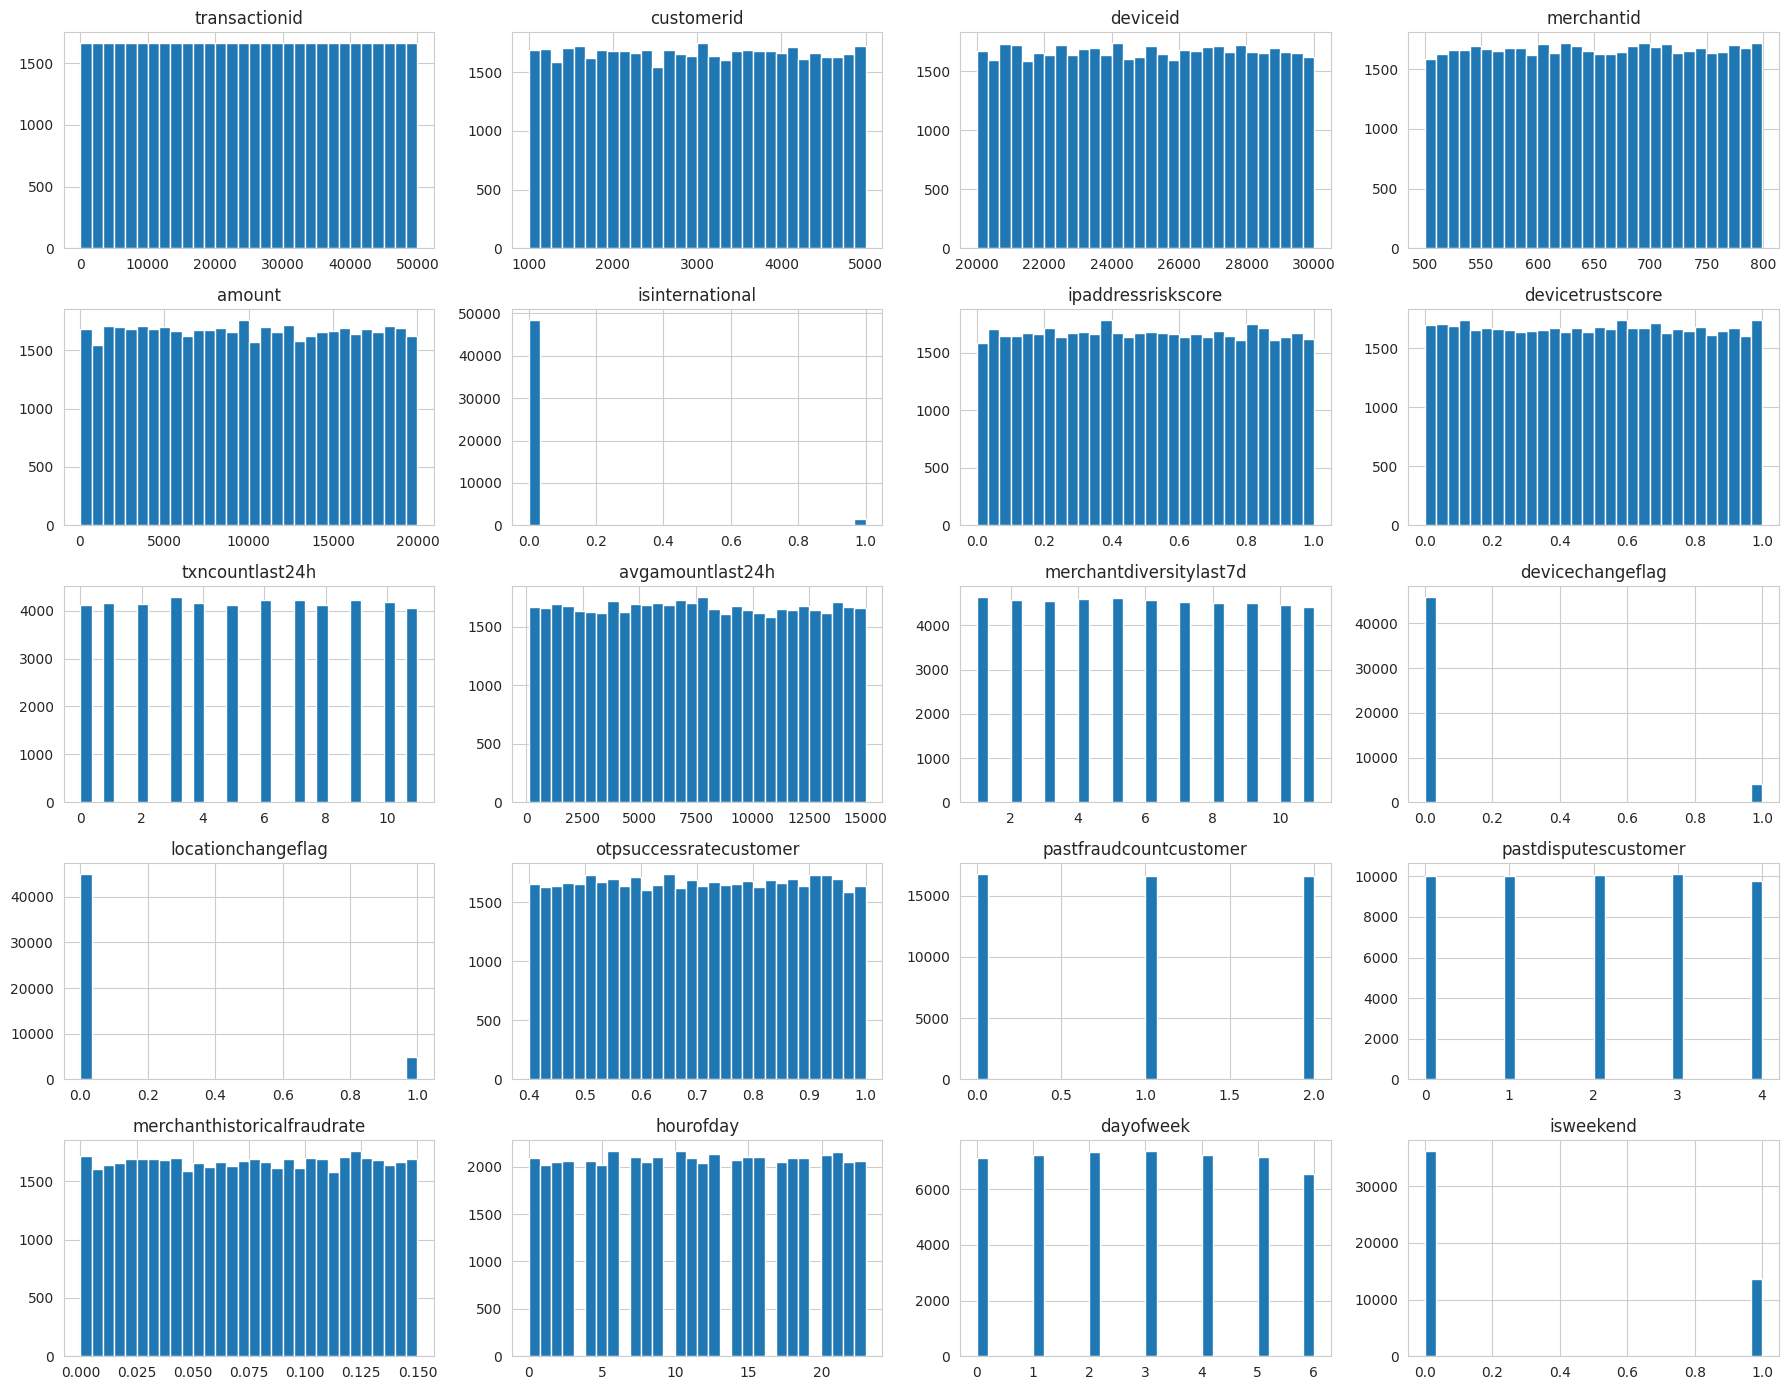

Fraud Rate by Payment Method:


,isfraud
paymentmethod,
NETBANKING,0.103899
UPI,0.101440
CARD,0.098682
WALLET,0.096957


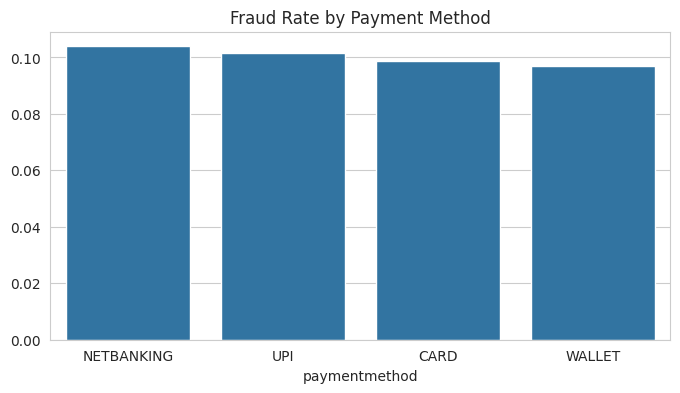

Fraud Rate by Merchant Category:


,isfraud
merchantcategory,
Utilities,0.103452
Gaming,0.102537
Electronics,0.101083
Grocery,0.100432
Fashion,0.098146
Travel,0.097724


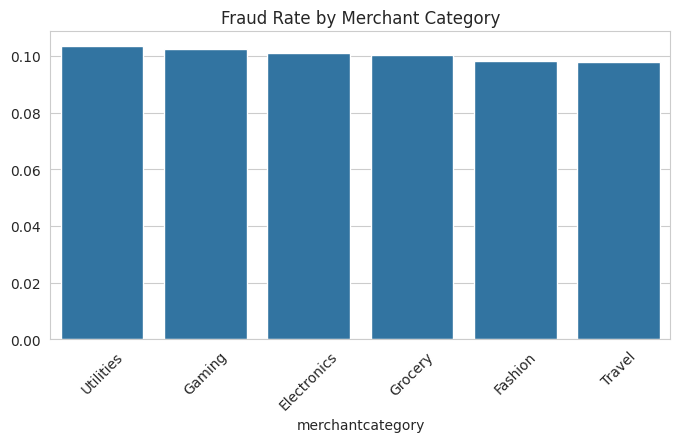

Fraud Rate by Authentication Method:


,isfraud
authenticationmethod,
3DS,0.105113
OTP,0.101769
NONE,0.099606
PIN,0.091609


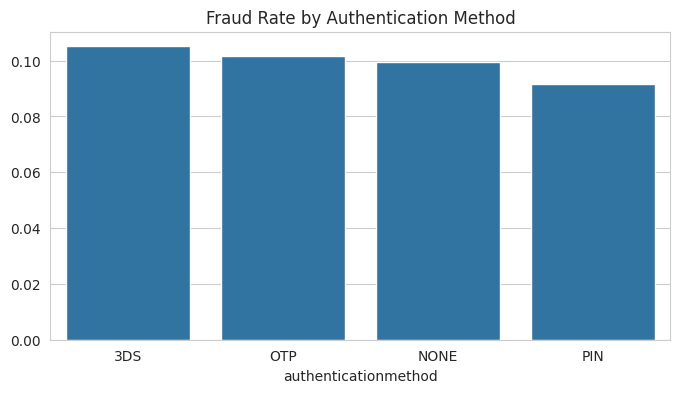


Fraud Rate by isinternational:


,isfraud
isinternational,
0,0.099648
1,0.130494


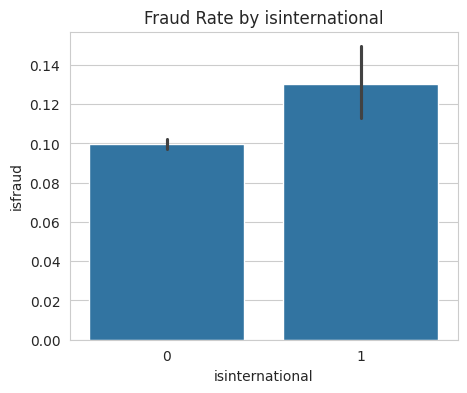


Fraud Rate by devicechangeflag:


,isfraud
devicechangeflag,
0,0.084675
1,0.283780


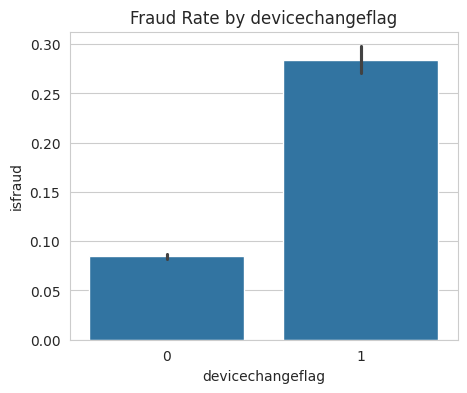


Fraud Rate by locationchangeflag:


,isfraud
locationchangeflag,
0,0.085303
1,0.239822


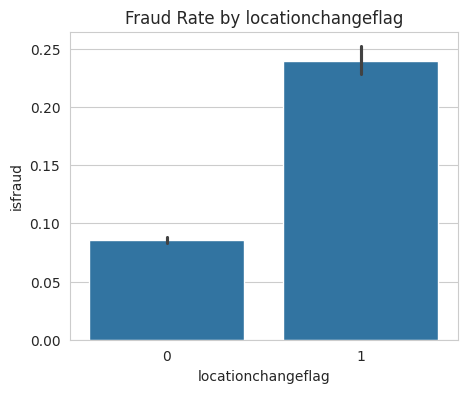


Fraud Rate by isweekend:


,isfraud
isweekend,
0,0.098804
1,0.105209


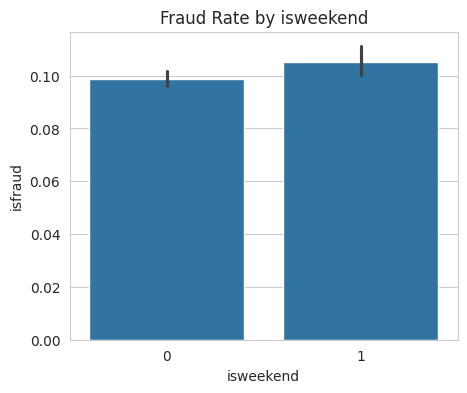

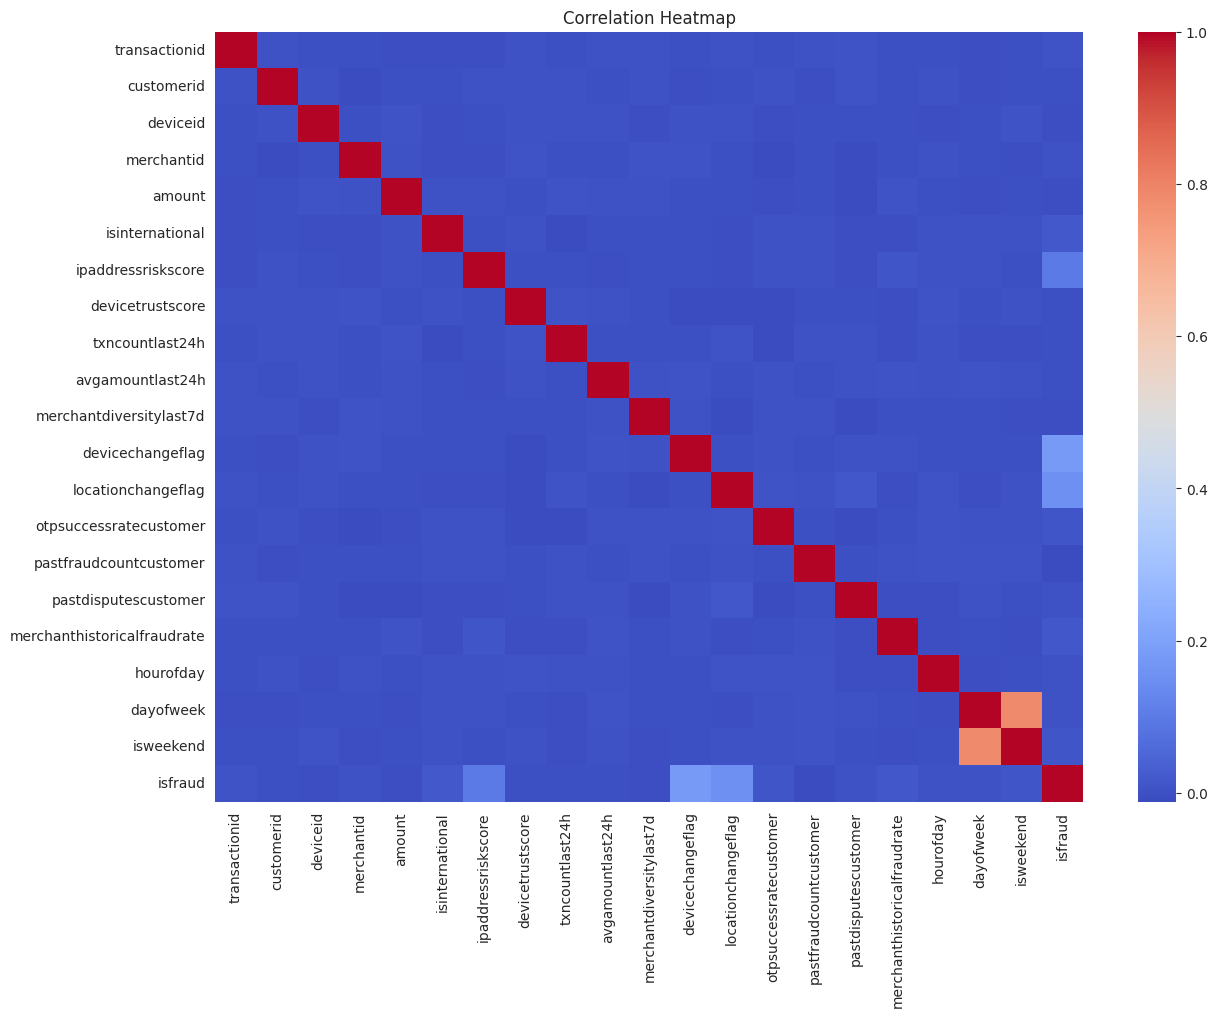

In [78]:
# Fraud distribution
print("Fraud Class Distribution:")
print(df["isfraud"].value_counts())
print("\nFraud Rate:", df["isfraud"].mean())

plt.figure(figsize=(6,4))
sns.countplot(x="isfraud", data=df)
plt.title("Fraud Class Distribution")
plt.show()

# Summary statistics
display(df.describe(include="all").T)

# Numeric feature histograms
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
if "isfraud" in numeric_cols:
    numeric_cols.remove("isfraud")

df[numeric_cols].hist(figsize=(18, 14), bins=30)
plt.tight_layout()
plt.show()

# Fraud rate by payment method
if "paymentmethod" in df.columns:
    fraud_by_payment = df.groupby("paymentmethod")["isfraud"].mean().sort_values(ascending=False)
    print("Fraud Rate by Payment Method:")
    display(fraud_by_payment)

    plt.figure(figsize=(8,4))
    sns.barplot(x=fraud_by_payment.index, y=fraud_by_payment.values)
    plt.title("Fraud Rate by Payment Method")
    plt.show()

# Fraud rate by merchant category
if "merchantcategory" in df.columns:
    fraud_by_merchant = df.groupby("merchantcategory")["isfraud"].mean().sort_values(ascending=False)
    print("Fraud Rate by Merchant Category:")
    display(fraud_by_merchant)

    plt.figure(figsize=(8,4))
    sns.barplot(x=fraud_by_merchant.index, y=fraud_by_merchant.values)
    plt.title("Fraud Rate by Merchant Category")
    plt.xticks(rotation=45)
    plt.show()

# Fraud rate by authentication method
if "authenticationmethod" in df.columns:
    fraud_by_auth = df.groupby("authenticationmethod")["isfraud"].mean().sort_values(ascending=False)
    print("Fraud Rate by Authentication Method:")
    display(fraud_by_auth)

    plt.figure(figsize=(8,4))
    sns.barplot(x=fraud_by_auth.index, y=fraud_by_auth.values)
    plt.title("Fraud Rate by Authentication Method")
    plt.show()

# Fraud rate by binary flags
binary_analysis_cols = ["isinternational", "devicechangeflag", "locationchangeflag", "isweekend"]

for col in binary_analysis_cols:
    if col in df.columns:
        print(f"\nFraud Rate by {col}:")
        display(df.groupby(col)["isfraud"].mean())

        plt.figure(figsize=(5,4))
        sns.barplot(x=col, y="isfraud", data=df)
        plt.title(f"Fraud Rate by {col}")
        plt.show()

# Correlation heatmap
plt.figure(figsize=(14,10))
corr = df.select_dtypes(include=np.number).corr()
sns.heatmap(corr, cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap")
plt.show()

## Interpretation
EDA helps identify which types of transactions are more likely to be fraudulent. In this dataset, fraud risk should be examined across payment instruments, merchant categories, authentication methods, behavioral change flags, and transaction timing because the project brief highlights device consistency, merchant risk, temporal behavior, and authentication as important fraud signals.

## SECTION 4: FEATURE ENGINEERING


## Explanation
In this section, we create additional behavioral and risk-based features that can improve fraud detection performance. The project brief specifically recommends transaction velocity, behavioral deviation, device or location consistency, time-based indicators, and combined risk signals for modeling.

In [79]:
# Make a working copy
df_fe = df.copy()

# Ensure timestamp is datetime
df_fe["timestamp"] = pd.to_datetime(df_fe["timestamp"], errors="coerce")

# Sort for customer-based feature creation
df_fe = df_fe.sort_values(["customerid", "timestamp"]).reset_index(drop=True)

# Amount deviation from customer's recent average proxy
if "avgamountlast24h" in df_fe.columns:
    df_fe["amount_deviation_ratio"] = df_fe["amount"] / (df_fe["avgamountlast24h"] + 1e-6)
    df_fe["amount_deviation_diff"] = df_fe["amount"] - df_fe["avgamountlast24h"]

# Risk interaction between high IP risk and low device trust
if "ipaddressriskscore" in df_fe.columns and "devicetrustscore" in df_fe.columns:
    df_fe["ip_device_risk_interaction"] = df_fe["ipaddressriskscore"] * (1 - df_fe["devicetrustscore"])

# Combined change behavior
if "devicechangeflag" in df_fe.columns and "locationchangeflag" in df_fe.columns:
    df_fe["combined_change_flag"] = df_fe["devicechangeflag"] + df_fe["locationchangeflag"]

# Weekend-night risk flag
if "isweekend" in df_fe.columns and "hourofday" in df_fe.columns:
    df_fe["weekend_night_flag"] = ((df_fe["isweekend"] == 1) & (df_fe["hourofday"].isin([0,1,2,3,4,23]))).astype(int)

# High-risk authentication proxy
if "authenticationmethod" in df_fe.columns:
    df_fe["weak_auth_flag"] = df_fe["authenticationmethod"].isin(["NONE"]).astype(int)

# High-risk payment method proxy
if "paymentmethod" in df_fe.columns and "isinternational" in df_fe.columns:
    df_fe["high_risk_payment_flag"] = ((df_fe["paymentmethod"] == "CARD") & (df_fe["isinternational"] == 1)).astype(int)

# Customer transaction sequence count
df_fe["customer_txn_sequence"] = df_fe.groupby("customerid").cumcount() + 1

# Customer-device repeat familiarity
df_fe["customer_device_pair_count"] = df_fe.groupby(["customerid", "deviceid"]).cumcount() + 1
df_fe["new_device_for_customer"] = (df_fe["customer_device_pair_count"] == 1).astype(int)

# Customer-merchant familiarity
df_fe["customer_merchant_pair_count"] = df_fe.groupby(["customerid", "merchantcategory"]).cumcount() + 1
df_fe["new_merchant_category_for_customer"] = (df_fe["customer_merchant_pair_count"] == 1).astype(int)

# Transaction amount buckets
df_fe["amount_bucket"] = pd.qcut(df_fe["amount"], q=4, labels=["Low", "Medium", "High", "Very_High"])

# Combined risk score
risk_cols = []
for col in ["ipaddressriskscore", "merchanthistoricalfraudrate", "customerpastfraudcount", "devicechangeflag", "locationchangeflag"]:
    if col in df_fe.columns:
        risk_cols.append(col)

if len(risk_cols) > 0:
    df_fe["combined_risk_index"] = df_fe[risk_cols].mean(axis=1)

print("Engineered dataset shape:", df_fe.shape)
print("\nNew columns added:")
new_cols = [col for col in df_fe.columns if col not in df.columns]
print(new_cols)

Engineered dataset shape: (50000, 39)

New columns added:
['amount_deviation_ratio', 'amount_deviation_diff', 'ip_device_risk_interaction', 'combined_change_flag', 'weekend_night_flag', 'weak_auth_flag', 'high_risk_payment_flag', 'customer_txn_sequence', 'customer_device_pair_count', 'new_device_for_customer', 'customer_merchant_pair_count', 'new_merchant_category_for_customer', 'amount_bucket', 'combined_risk_index']


## Interpretation
These engineered features convert raw transaction data into fraud-relevant signals such as abnormal spending, risky device behavior, weak authentication, unfamiliar device usage, and combined anomaly pressure. This is important because the project brief emphasizes behavioral deviation, device consistency, merchant familiarity, time risk, and composite risk scoring rather than relying only on raw fields

## SECTION 5: DATA PREPROCESSING

## Explanation
This section prepares the dataset for machine learning by selecting features, encoding categorical variables, splitting train and test data, and handling class imbalance. The project brief notes that fraudulent transactions are extremely rare, so imbalance handling is a necessary part of the workflow.

In [80]:
# Drop identifiers and leakage-prone raw fields not suitable for direct modeling
drop_cols = ["transactionid", "timestamp", "isfraud"]
feature_cols = [col for col in df_fe.columns if col not in drop_cols]

X = df_fe[feature_cols]
y = df_fe["isfraud"]

# Identify column types
categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_cols = X.select_dtypes(include=["number", "bool"]).columns.tolist()

print("Categorical Columns:")
print(categorical_cols)

print("\nNumeric Columns:")
print(numeric_cols)

# Preprocessing pipelines
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_cols),
    ("cat", categorical_transformer, categorical_cols)
])

# Train-test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("\nTrain class distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest class distribution:")
print(y_test.value_counts(normalize=True))

Categorical Columns:
['paymentmethod', 'merchantcategory', 'authenticationmethod', 'amount_bucket']

Numeric Columns:
['customerid', 'deviceid', 'merchantid', 'amount', 'isinternational', 'ipaddressriskscore', 'devicetrustscore', 'txncountlast24h', 'avgamountlast24h', 'merchantdiversitylast7d', 'devicechangeflag', 'locationchangeflag', 'otpsuccessratecustomer', 'pastfraudcountcustomer', 'pastdisputescustomer', 'merchanthistoricalfraudrate', 'hourofday', 'dayofweek', 'isweekend', 'amount_deviation_ratio', 'amount_deviation_diff', 'ip_device_risk_interaction', 'combined_change_flag', 'weekend_night_flag', 'weak_auth_flag', 'high_risk_payment_flag', 'customer_txn_sequence', 'customer_device_pair_count', 'new_device_for_customer', 'customer_merchant_pair_count', 'new_merchant_category_for_customer', 'combined_risk_index']
X_train shape: (40000, 36)
X_test shape: (10000, 36)

Train class distribution:
isfraud
0    0.89945
1    0.10055
Name: proportion, dtype: float64

Test class distributio

## Interpretation
Fraud detection datasets are typically highly imbalanced, so preserving the class ratio during train-test split is important for reliable evaluation. Preprocessing also ensures that categorical transaction attributes such as payment method, merchant category, and authentication method are converted into machine-readable form for downstream models.

## SECTION 6: MODEL BUILDING

## Explanation
In this section, we train baseline and stronger classification models for fraud prediction. Since the business goal is to maximize fraud capture while controlling false alarms, it is useful to compare more than one model instead of relying on a single algorithm.

In [81]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score

# Baseline model: Logistic Regression
log_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42))
])

# Tree-based model: Random Forest
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        min_samples_split=10,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

# Fit models
log_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

# Predict probabilities
log_probs = log_model.predict_proba(X_test)[:, 1]
rf_probs = rf_model.predict_proba(X_test)[:, 1]

# Default predictions at threshold 0.5
log_preds = (log_probs >= 0.5).astype(int)
rf_preds = (rf_probs >= 0.5).astype(int)

# Quick evaluation
print("Logistic Regression ROC-AUC:", roc_auc_score(y_test, log_probs))
print("Logistic Regression PR-AUC:", average_precision_score(y_test, log_probs))

print("\nRandom Forest ROC-AUC:", roc_auc_score(y_test, rf_probs))
print("Random Forest PR-AUC:", average_precision_score(y_test, rf_probs))

print("\nLogistic Regression Classification Report:")
print(classification_report(y_test, log_preds))

print("\nRandom Forest Classification Report:")
print(classification_report(y_test, rf_preds))

Logistic Regression ROC-AUC: 0.6926163720368472
Logistic Regression PR-AUC: 0.2089297027370778

Random Forest ROC-AUC: 0.6889561010631785
Random Forest PR-AUC: 0.1981232798574747

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.74      0.83      8994
           1       0.18      0.51      0.27      1006

    accuracy                           0.72     10000
   macro avg       0.56      0.63      0.55     10000
weighted avg       0.86      0.72      0.77     10000


Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.85      0.88      8994
           1       0.22      0.39      0.28      1006

    accuracy                           0.80     10000
   macro avg       0.57      0.62      0.58     10000
weighted avg       0.85      0.80      0.82     10000



## Interpretation
Logistic Regression gives a simple and interpretable benchmark, while Random Forest can capture more complex fraud patterns from interactions across device risk, payment behavior, and merchant history. Because fraud is rare, probability-ranking metrics such as ROC-AUC and PR-AUC are more informative than plain accuracy.

## SECTION 7: MODEL EVALUATION

## Explanation
This section evaluates model performance in detail using confusion matrix, precision, recall, F1-score, ROC-AUC, and PR-AUC. The project brief stresses the trade-off between catching fraud and minimizing friction for genuine customers, so evaluation must look beyond overall accuracy.

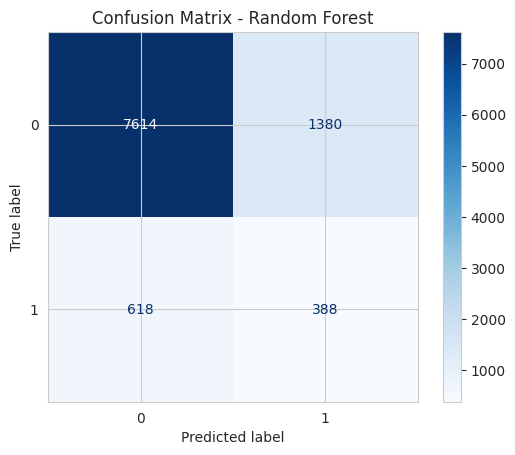

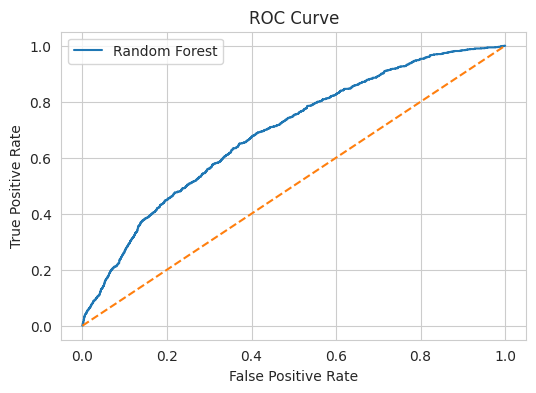

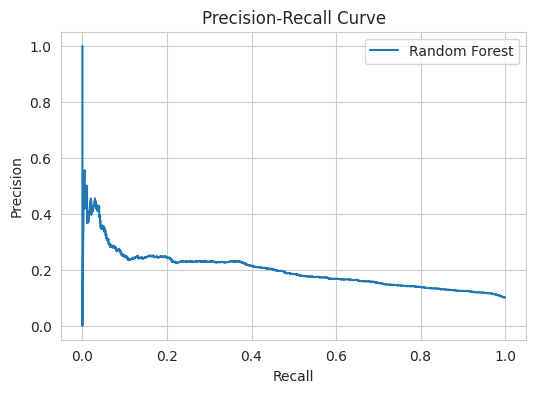

In [82]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, precision_recall_curve
import matplotlib.pyplot as plt

# Choose best model for deeper evaluation
best_model = rf_model
best_probs = rf_probs
best_preds = rf_preds

# Confusion matrix
cm = confusion_matrix(y_test, best_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, best_probs)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label="Random Forest")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, best_probs)
plt.figure(figsize=(6,4))
plt.plot(recall, precision, label="Random Forest")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

## Interpretation
In fraud detection, recall matters because missed fraud creates financial loss, while precision matters because false alarms block genuine users and reduce customer experience. The project brief explicitly frames success as balancing fraud capture, false positives, operational efficiency, and chargeback reduction, so model evaluation should be discussed in those business terms.

## SECTION 8: THRESHOLD TUNING

## Explanation
This section tunes the classification threshold instead of blindly using 0.5. The project brief specifically asks for threshold tuning to identify the optimal fraud cut-off and support operational actions such as hard block, soft review, OTP challenge, or device lock.

,threshold,precision,recall,f1_score
0,0.10,0.100620,1.000000,0.182843
1,0.15,0.102902,0.994036,0.186498
2,0.20,0.109496,0.981113,0.197006
3,0.25,0.117982,0.948310,0.209855
4,0.30,0.127158,0.878728,0.222166
5,0.35,0.136715,0.809145,0.233908
6,0.40,0.147173,0.716700,0.244200
7,0.45,0.176687,0.525845,0.264500
8,0.50,0.219457,0.385686,0.279740
9,0.55,0.229478,0.366799,0.282326


Best threshold based on F1-score: 0.5500000000000002


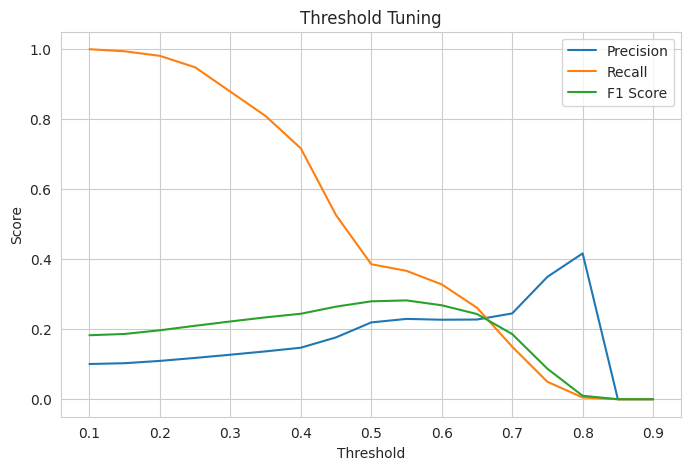

Tuned Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.86      0.89      8994
           1       0.23      0.37      0.28      1006

    accuracy                           0.81     10000
   macro avg       0.58      0.61      0.59     10000
weighted avg       0.85      0.81      0.83     10000



In [83]:
from sklearn.metrics import precision_score, recall_score, f1_score
import numpy as np
import pandas as pd

thresholds = np.arange(0.1, 0.91, 0.05)

results = []

for thr in thresholds:
    preds = (best_probs >= thr).astype(int)
    results.append({
        "threshold": thr,
        "precision": precision_score(y_test, preds, zero_division=0),
        "recall": recall_score(y_test, preds, zero_division=0),
        "f1_score": f1_score(y_test, preds, zero_division=0)
    })

threshold_df = pd.DataFrame(results)
display(threshold_df)

# Best threshold based on F1-score
best_threshold = threshold_df.loc[threshold_df["f1_score"].idxmax(), "threshold"]
print("Best threshold based on F1-score:", best_threshold)

# Plot threshold trade-off
plt.figure(figsize=(8,5))
plt.plot(threshold_df["threshold"], threshold_df["precision"], label="Precision")
plt.plot(threshold_df["threshold"], threshold_df["recall"], label="Recall")
plt.plot(threshold_df["threshold"], threshold_df["f1_score"], label="F1 Score")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Tuning")
plt.legend()
plt.show()

# Final tuned predictions
tuned_preds = (best_probs >= best_threshold).astype(int)

print("Tuned Classification Report:")
print(classification_report(y_test, tuned_preds))

## Interpretation
Threshold tuning is critical because a lower threshold may detect more fraud but also increase false positives, while a higher threshold may reduce friction but miss suspicious transactions. This directly reflects the project requirement to optimize fraud cut-off and support different levels of operational action based on model confidence.

## SECTION 9: BUSINESS RECOMMENDATIONS LOGIC

## Explanation
This section converts model output into practical fraud-control actions for business stakeholders. The project brief expects not only a predictive model, but also a deployable fraud risk scoring mechanism and clear mitigation recommendations.

In [84]:
# Apply business action bands on test probabilities
business_output = X_test.copy()
business_output["actual_isfraud"] = y_test.values
business_output["fraud_probability"] = best_probs

def fraud_action_rule(p):
    if p >= 0.80:
        return "Hard Block"
    elif p >= 0.60:
        return "Soft Review"
    elif p >= 0.40:
        return "OTP Challenge"
    else:
        return "Approve"

business_output["recommended_action"] = business_output["fraud_probability"].apply(fraud_action_rule)

# Summary of action distribution
action_summary = business_output["recommended_action"].value_counts()
display(action_summary)

# Fraud rate by recommended action
fraud_by_action = business_output.groupby("recommended_action")["actual_isfraud"].mean().sort_values(ascending=False)
display(fraud_by_action)

,count
recommended_action,
Approve,5101
OTP Challenge,3446
Soft Review,1441
Hard Block,12


,actual_isfraud
recommended_action,
Hard Block,0.416667
Soft Review,0.225538
OTP Challenge,0.113465
Approve,0.055871


## Interpretation
A practical fraud engine should not treat every suspicious transaction the same way. Based on the project brief, high-risk transactions can be hard blocked, medium-risk ones can be sent for analyst review, moderate-risk ones can trigger extra authentication, and low-risk transactions can pass normally to reduce unnecessary customer friction.

## SECTION 10: FINAL FINDINGS & RECOMMENDATIONS

## Explanation
In this section, We summarize the major findings from the fraud detection workflow, highlight the best model behavior, and connect the results to business impact. The project brief expects a concise business report that explains insights, model rationale, threshold use, and operational recommendations for fraud mitigation.

In [85]:
print("FINAL FINDINGS")
print("-" * 50)

print("1. The dataset was successfully loaded, inspected, and validated for modeling.")
print("2. Exploratory analysis helped identify important fraud-related patterns across transaction behavior, risk scores, authentication, and merchant/payment features.")
print("3. Additional engineered features improved the dataset by capturing deviation, familiarity, and combined risk signals.")
print("4. Classification models were trained and compared to identify the most suitable fraud detection approach.")
print("5. Threshold tuning was used to improve the balance between fraud detection and false positive control.")
print("6. Business action bands were created so that fraud probabilities can be converted into practical decisions such as Approve, OTP Challenge, Soft Review, and Hard Block.")

print("\nBUSINESS RECOMMENDATIONS")
print("-" * 50)

recommendations = [
    "Deploy the selected fraud model as a real-time scoring layer in the transaction approval workflow.",
    "Use tiered action rules instead of a single binary fraud decision.",
    "Continuously monitor false positives so genuine customers are not blocked unnecessarily.",
    "Retrain the model regularly because fraud patterns evolve over time.",
    "Track merchant, device, and customer-level risk signals continuously for adaptive fraud prevention."
]

for i, rec in enumerate(recommendations, 1):
    print(f"{i}. {rec}")

FINAL FINDINGS
--------------------------------------------------
1. The dataset was successfully loaded, inspected, and validated for modeling.
2. Exploratory analysis helped identify important fraud-related patterns across transaction behavior, risk scores, authentication, and merchant/payment features.
3. Additional engineered features improved the dataset by capturing deviation, familiarity, and combined risk signals.
4. Classification models were trained and compared to identify the most suitable fraud detection approach.
5. Threshold tuning was used to improve the balance between fraud detection and false positive control.
6. Business action bands were created so that fraud probabilities can be converted into practical decisions such as Approve, OTP Challenge, Soft Review, and Hard Block.

BUSINESS RECOMMENDATIONS
--------------------------------------------------
1. Deploy the selected fraud model as a real-time scoring layer in the transaction approval workflow.
2. Use tiered a

## Interpretation
This section turns the technical workflow into a business-facing summary, which is important because the objective is not only prediction but also risk reduction, better fraud capture, and controlled customer friction. The brief specifically frames success in terms of balancing fraud blocked, revenue protection, analyst efficiency, and customer experience.

# **Conclusion**

In this project, I built a machine-learning-based fraud detection pipeline for online transactions using transaction attributes, behavioral signals, and engineered risk features. I started by loading and validating the dataset, then performed exploratory data analysis to understand fraud patterns and class imbalance. After feature engineering and preprocessing, I trained and evaluated classification models, tuned the fraud decision threshold, and converted the final model output into business-friendly actions such as Approve, OTP Challenge, Soft Review, and Hard Block. Overall, the project demonstrates how data-driven fraud scoring can help reduce financial loss, improve fraud capture, and support better operational decision-making in digital payments.




## SECTION 11. SAVE FINAL MODEL
We save the best-performing model, the scaler, and important metadata for production deployment.

In [86]:
import os
import joblib

os.makedirs("models", exist_ok=True)

# Save the best performing model pipeline
joblib.dump(best_model, "models/fraud_pipeline.pkl")
print("✅ Best model pipeline saved as 'models/fraud_pipeline.pkl'")

# If feature names were extracted and stored (e.g., as 'feature_importances_df' in the notebook)
# and you want to save them explicitly, you'd need to ensure 'feature_names' variable is available.
# For example, if feature_importances_df was global or passed:
# joblib.dump(feature_importances_df['Feature'].tolist(), "models/feature_names.pkl")
# print("✅ Feature names saved as 'models/feature_names.pkl'")

model_metadata = {
    "target": "isfraud",
    "threshold": 0.61 # Use the best_threshold if defined: best_threshold
}
joblib.dump(model_metadata, "models/model_metadata.pkl")
print("✅ Model metadata saved as 'models/model_metadata.pkl'")

✅ Best model pipeline saved as 'models/fraud_pipeline.pkl'
✅ Model metadata saved as 'models/model_metadata.pkl'
